Installation of dependencies

In [3]:
pip install dquant arch yfinance

  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached websockets-16.0-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.5-py3-none-any.whl (144 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached websockets-16.0-cp312-cp312-win_amd64.whl


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Example with DQuant

[*********************100%***********************]  1 of 1 completed


Подготовка данных: |█████████████████████████████████████████████████░|  99.90%   Осталось 0.06 секундддд
1 trees
Train error:       0.9600828302609558
Validation error:  0.8605752007741929
Train r2:          0.039917169739044106
Validation r2:     -0.11670063711857902
Затрачено времени: 3.9497687816619873 сек
2 trees
Train error:       0.9242700667392985
Validation error:  0.8545751200613675
Train r2:          0.07572993326070157
Validation r2:     -0.1086404158334045
Затрачено времени: 8.400510787963867 сек
3 trees
Train error:       0.8901105121474328
Validation error:  0.8458786575751113
Train r2:          0.10988948785256714
Validation r2:     -0.09703235934646033
Затрачено времени: 13.44121789932251 сек
4 trees
Train error:       0.8594448236192584
Validation error:  0.8378425264760683
Train r2:          0.14055517638074136
Validation r2:     -0.0865964234141238
Затрачено времени: 19.3398756980896 сек
5 trees
Train error:       0.8302883665507619
Validation error:  0.829943253177

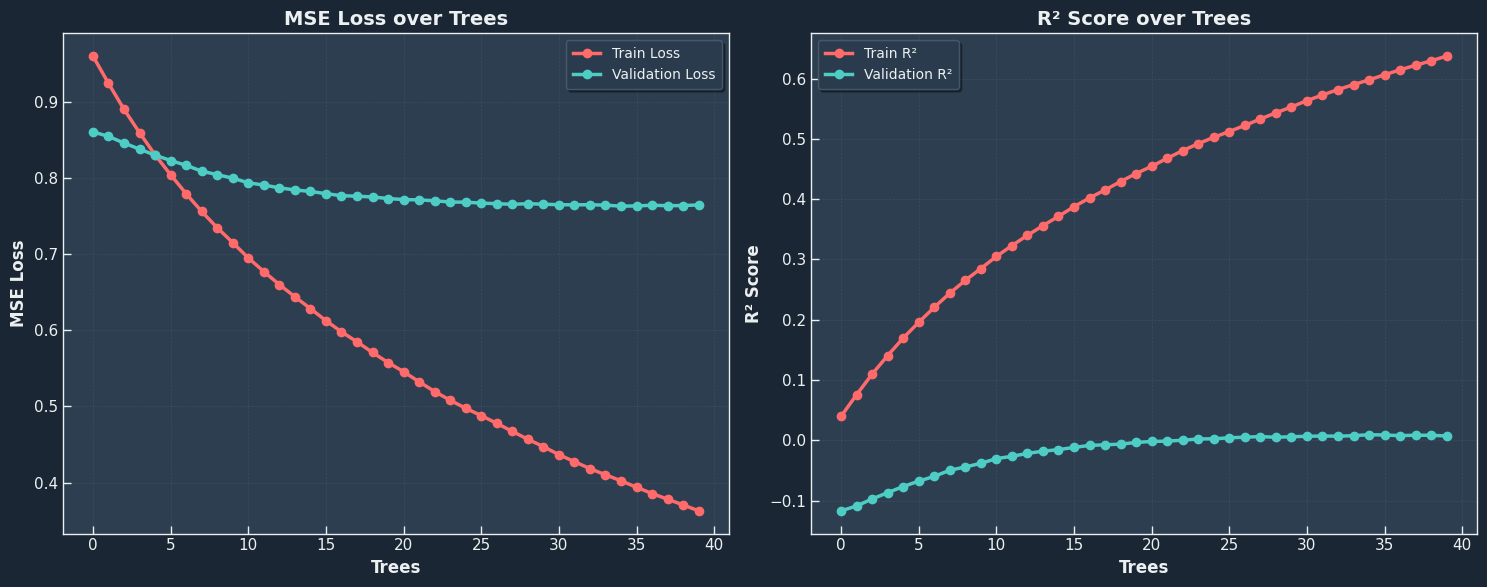

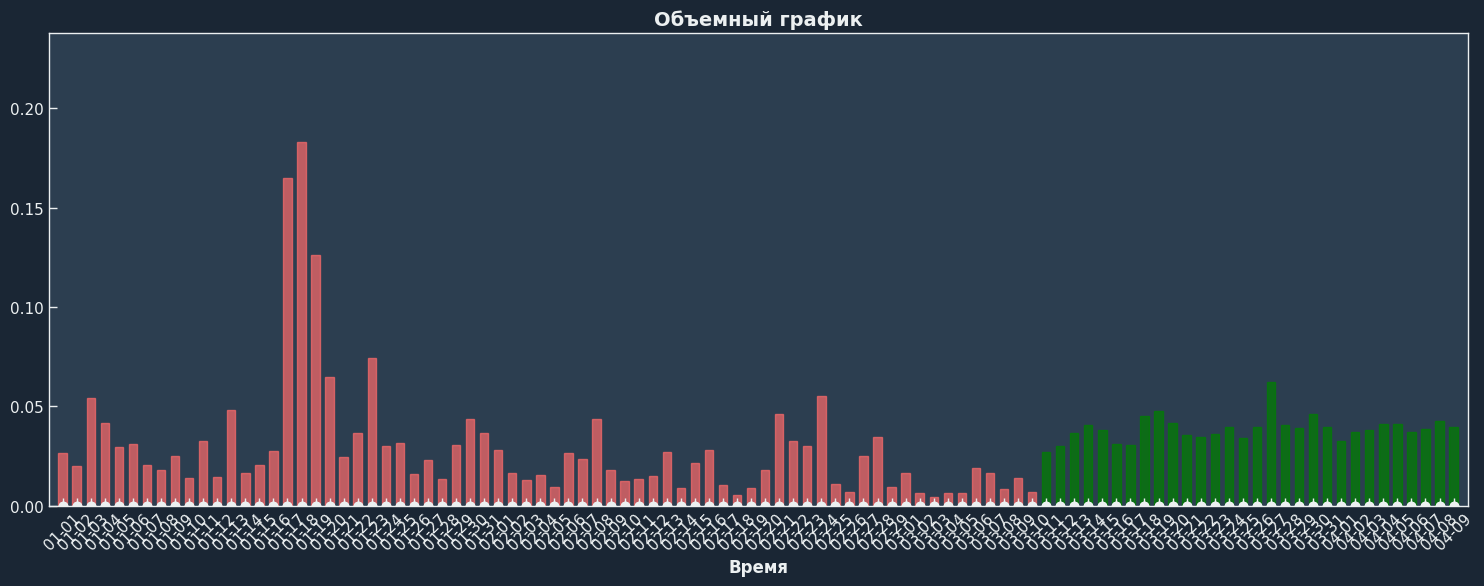

[0.02717723 0.02998355 0.03667842 0.04061031 0.03814143 0.03090188
 0.03050342 0.04519274 0.04769433 0.04175545 0.03576446 0.03447296
 0.03589699 0.03981598 0.03384372 0.03971248 0.06241815 0.04083324
 0.03889441 0.04610214 0.03963728 0.03260835 0.03714336 0.03800761
 0.04108912 0.04109729 0.03731998 0.03843959 0.04266656 0.03969154]


In [10]:
import pandas as pd
import yfinance as yf
import datetime as dt
from dquant.models import VolClustXGB


# 1. Load data
start = dt.datetime(2020, 1, 1)
end = dt.datetime(2023, 1, 1)
ticker = "BTC-USD"
df = yf.download(ticker, start=start, end=end, interval='1d')
df = pd.DataFrame({
    'open': df[('Open', ticker)].values,
    'high': df[('High', ticker)].values,
    'low': df[('Low', ticker)].values,
    'close': df[('Close', ticker)].values,
    'volume': df[('Volume', ticker)].values
}, index=df.index)


# 2. Create model
model = VolClustXGB({}, early_stopping=True)

# 3. Train model
features = [
    'TR',
    'returns',
    'abs_returns',
    'gap',
    'body',
    'shadow',
    'close_position',
    'roll_atr_14'
]
model.fit(df, feature_list=features, input_bars=70, horizon=30, trees_count=200, show_results=True)

# 4. Make forecast
rez = model.forecast(df.iloc[-70:].copy(), show=True)
print(rez)
model.save("btcmod")

Example with GARCH

In [9]:
import pandas as pd
import yfinance as yf
import datetime as dt
import numpy as np
from arch import arch_model


start = dt.datetime(2020, 1, 1)
end = dt.datetime(2023, 1, 1)
ticker = "BTC-USD"
df = yf.download(ticker, start=start, end=end, interval='1d')
df = pd.DataFrame({
    'open': df[('Open', ticker)].values,
    'high': df[('High', ticker)].values,
    'low': df[('Low', ticker)].values,
    'close': df[('Close', ticker)].values,
    'volume': df[('Volume', ticker)].values
}, index=df.index)

df['returns'] = np.maximum(
    (df['high'] - df['low']) / df['close'],
    np.maximum(
        (np.abs(df['high'] - df['close'].shift(1)))/ df['close'],
        (np.abs(df['low'] - df['close'].shift(1)))/ df['close']
    )
)
arr = df['returns']

data = (df.dropna())

# Обучение модели GARCH(1,1)
returns = data['returns'].values

# Создание модели GARCH(1,1) с нормальным распределением
model = arch_model(returns, vol='GARCH', p=1, q=1, o=1, dist='normal')
model_fit = model.fit(disp='off')  # disp='off' отключает вывод подробной информации

# Вывод результатов
print(model_fit.summary())

# Расчет долгосрочной (безусловной) волатильности
omega = model_fit.params['omega']
alpha = model_fit.params['alpha[1]']
beta = model_fit.params['beta[1]']
unconditional_variance = omega / (1 - alpha - beta)
unconditional_volatility = np.sqrt(unconditional_variance)
print(f"Долгосрочная волатильность: {unconditional_volatility:.4f}%")
print(f"Персистентность волатильности (alpha + beta): {alpha + beta:.4f}")

# Расчет времени полураспада шока волатильности
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Время полураспада шока волатильности: {half_life:.1f} дней")


# Получение стандартизированных остатков
resid = model_fit.resid
std_resid = resid / model_fit.conditional_volatility

# Прогнозирование на 30 дней вперед
forecast_horizon = 30
forecasts = model_fit.forecast(
    horizon=forecast_horizon,
    method='simulation',
    simulations=10000)

# Извлечение прогнозов волатильности
forecast_variance = forecasts.variance.iloc[-1].values
forecast_volatility = np.sqrt(forecast_variance)

last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=forecast_horizon + 1)[1:]


# Вывод прогнозных значений
print("\nПрогноз волатильности на ближайшие дни:")
for i, (date, vol) in enumerate(zip(forecast_dates[:24], forecast_volatility[:24])):
    print(f"{date.date()}: {vol:.4f}%")

# Долгосрочный прогноз волатильности
long_term_volatility = forecast_volatility[-1]
print(f"\nДолгосрочный прогноз волатильности (через {forecast_horizon} дней): {long_term_volatility:.4f}%")

[*********************100%***********************]  1 of 1 completed
C:\Users\sinma\PycharmProjects\DQuant_Research\.venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001519. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:                2070.49
Distribution:                  Normal   AIC:                          -4130.98
Method:            Maximum Likelihood   BIC:                          -4105.99
                                        No. Observations:                 1095
Date:                Fri, May 08 2026   Df Residuals:                     1094
Time:                        12:26:12   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0449  4.901e-03      9.159  5.230e-20 [3.